# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

Nesta primeira etapa, realizamos a importação das bibliotecas fundamentais e do conjunto de dados **MNIST** (`mnist_784`) utilizando o módulo `scikit-learn`.

O dataset MNIST contém 70.000 imagens de dígitos manuscritos (0 a 9). Ao definir `as_frame=False`, garantimos a recuperação dos dados diretamente em *arrays* NumPy, o que otimiza o processamento matricial e a manipulação dos pixels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Carregamento do dataset MNIST via scikit-learn
print("Baixando/Carregando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Dataset carregado com sucesso!")

# Divisão inicial em atributos (X) e rótulos (y)
X, y = mnist.data, mnist.target.astype(int)

Baixando/Carregando o dataset MNIST...
Dataset carregado com sucesso!


### 1.1 Dimensionalidade dos Dados e Distribuição das Classes

Abaixo, verificamos o formato das matrizes de atributos ($X$) e dos rótulos ($y$). Em seguida, analisamos a distribuição das classes para confirmar se o conjunto de dados apresenta balanceamento entre os dígitos de 0 a 9.

Dimensão da matriz de atributos (X): (70000, 784)
Dimensão do vetor de rótulos (y): (70000,)

--- Distribuição das Classes no MNIST ---
 Dígito  Total de Amostras  Proporção (%)
      0               6903           9.86
      1               7877          11.25
      2               6990           9.99
      3               7141          10.20
      4               6824           9.75
      5               6313           9.02
      6               6876           9.82
      7               7293          10.42
      8               6825           9.75
      9               6958           9.94


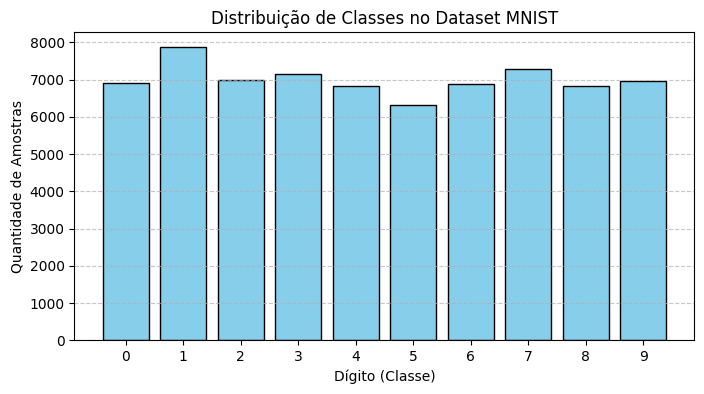

In [2]:
# Exibição das dimensões dos dados
print(f"Dimensão da matriz de atributos (X): {X.shape}")
print(f"Dimensão do vetor de rótulos (y): {y.shape}")

# Contagem das ocorrências de cada classe (dígitos de 0 a 9)
classes_unicas, contagem = np.unique(y, return_counts=True)

# Apresentação do balanceamento em formato de tabela
df_balanceamento = pd.DataFrame({
    'Dígito': classes_unicas,
    'Total de Amostras': contagem,
    'Proporção (%)': np.round((contagem / len(y)) * 100, 2)
})

print("\n--- Distribuição das Classes no MNIST ---")
print(df_balanceamento.to_string(index=False))

# Gráfico de barras para visualização do balanceamento
plt.figure(figsize=(8, 4))
plt.bar(classes_unicas, contagem, color='skyblue', edgecolor='black')
plt.xlabel('Dígito (Classe)')
plt.ylabel('Quantidade de Amostras')
plt.title('Distribuição de Classes no Dataset MNIST')
plt.xticks(classes_unicas)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 1.2 Grade Visual das Imagens de Exemplo

Para inspecionar visualmente os dados, geramos uma grade de dimensão $2 \times 5$ utilizando a biblioteca `matplotlib`. A função busca e exibe a primeira ocorrência de cada dígito (de 0 a 9) no dataset, acompanhada de seu respectivo rótulo original.

Como cada amostra é um vetor unidimensional de 784 elementos, aplicamos a operação de `.reshape(28, 28)` para reconstruir a matriz original da imagem.

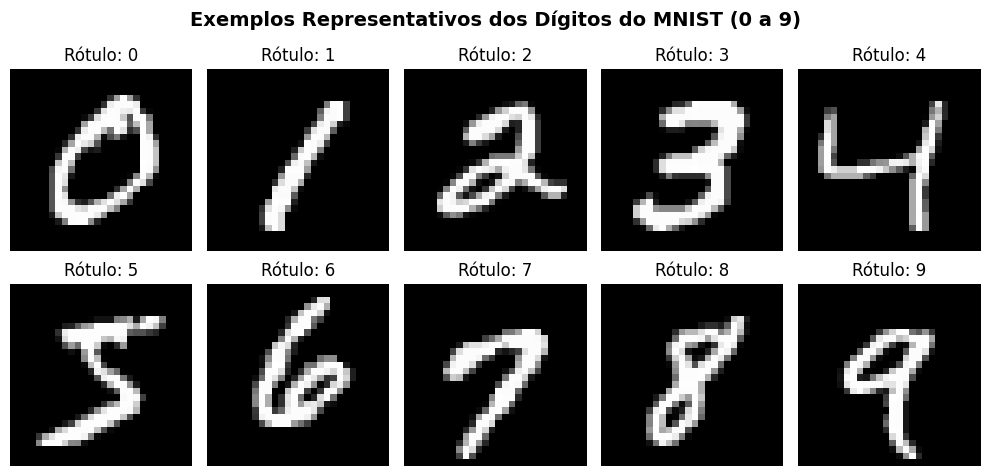

In [3]:
# Criação de subplots 2x5
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle('Exemplos Representativos dos Dígitos do MNIST (0 a 9)', fontsize=14, fontweight='bold')

# Iteração para encontrar a primeira ocorrência de cada dígito
for digito in range(10):
    # Encontra o índice da primeira ocorrência do dígito
    idx = np.where(y == digito)[0][0]

    # Redimensiona o vetor de 784 para 28x28 pixels
    imagem_2d = X[idx].reshape(28, 28)

    # Determina a posição da célula na grade (linha, coluna)
    ax = axes[digito // 5, digito % 5]
    ax.imshow(imagem_2d, cmap='gray')
    ax.set_title(f"Rótulo: {y[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

### 1.3 Interpretação da Estrutura dos Dados

A análise da estrutura do dataset MNIST revela as seguintes características fundamentais para o modelamento:

* **Representação Vetorial vs. Bidimensional:** Cada amostra de imagem possui originalmente uma dimensão espacial de $28 \times 28$ pixels em escala de cinza. Para que esses dados possam ser processados por algoritmos tradicionais de aprendizado estatístico, as imagens são linearizadas (*flattened*), resultando em um vetor unidimensional de $784$ atributos ($28 \times 28 = 784 \text{ features}$).
* **Escala de Intensidade de Pixels:** Os valores de cada pixel variam na escala numérica inteira de **0 a 255**:
  * **0 (Zero):** Representa o fundo totalmente preto da imagem.
  * **255:** Representa a intensidade máxima de branco (os traços principais do dígito manuscrito).
  * **Valores intermediários (1 a 254):** Correspondem às gradações de cinza presentes nas bordas e suavizações dos traços.
* **Diagnóstico de Balanceamento:** Conforme demonstrado na tabela e gráfico da seção 1.1, as 70.000 amostras estão distribuídas de maneira uniforme entre os 10 dígitos (aproximadamente $9.8\%$ a $11.3\%$ por classe), indicando que o dataset é naturalmente balanceado e não exigirá técnicas de reamostragem (como undersampling ou oversampling).

# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

Nesta fase, preparamos o dataset para o treinamento, validação e teste dos modelos de Machine Learning/Deep Learning.

O pipeline contempla:
1. **Divisão Estratificada:** Separação do dataset original em conjuntos de **Treino (70%)**, **Validação (10%)** e **Teste (20%)**, preservando rigorosamente a proporção das classes (dígitos de 0 a 9) em cada subconjunto através do parâmetro `stratify`.
2. **Normalização/Escalonamento:** Redimensionamento da escala de intensidade dos pixels do intervalo original $[0, 255]$ para a escala contínua $[0.0, 1.0]$.

### 2.1 Divisão Estratificada (Treino, Validação e Teste)

Realizamos a divisão em duas etapas utilizando o `train_test_split` do `scikit-learn`:
1. Primeiro, separamos **20%** dos dados para o conjunto final de **Teste** (`X_test`, `y_test`).
2. Dos **80%** restantes (conjunto de treino/validação temporário), alocamos **12.5%** para **Validação** (`X_val`, `y_val`) e **87.5%** para **Treino** (`X_train`, `y_train`).
   * *Nota:* $12.5\% \text{ de } 80\% = 10\%$ do total geral do dataset. Assim, obtemos exatamente a proporção **70% Treino / 10% Validação / 20% Teste**.

In [4]:
from sklearn.model_selection import train_test_split

# 1ª Divisão: Separa 20% para Teste e 80% para Treino + Validação
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2ª Divisão: Dos 80% temporários, separa 12.5% para Validação (12.5% de 80% = 10% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

# Exibição dos tamanhos finais dos conjuntos
total_amostras = len(X)
print(f"Total de amostras no dataset: {total_amostras}")
print(f"Conjunto de Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/total_amostras:.0%})")
print(f"Conjunto de Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/total_amostras:.0%})")
print(f"Conjunto de Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/total_amostras:.0%})")

# Validação do balanceamento de classes em cada subconjunto
df_strat = pd.DataFrame({
    'Classe': np.unique(y),
    'Treino (%)': np.round(np.bincount(y_train) / len(y_train) * 100, 2),
    'Validação (%)': np.round(np.bincount(y_val) / len(y_val) * 100, 2),
    'Teste (%)': np.round(np.bincount(y_test) / len(y_test) * 100, 2)
})

print("\n--- Verificação da Estratificação por Classe (%) ---")
print(df_strat.to_string(index=False))

Total de amostras no dataset: 70000
Conjunto de Treino:    49000 amostras (70%)
Conjunto de Validação: 7000 amostras (10%)
Conjunto de Teste:     14000 amostras (20%)

--- Verificação da Estratificação por Classe (%) ---
 Classe  Treino (%)  Validação (%)  Teste (%)
      0        9.86           9.86       9.86
      1       11.25          11.26      11.25
      2        9.99           9.99       9.99
      3       10.20          10.20      10.20
      4        9.75           9.74       9.75
      5        9.02           9.01       9.02
      6        9.82           9.83       9.82
      7       10.42          10.41      10.42
      8        9.75           9.76       9.75
      9        9.94           9.94       9.94


### 2.2 Normalização / Escalonamento dos Pixels

Como os dados de imagem possuem valores inteiros de $0$ a $255$, aplicamos a divisão direta por $255.0$ para reescalar todas as *features* para o intervalo $[0.0, 1.0]$.

**Regra Importante de Prevenção a Data Leakage:**
Para evitar vazamento de informação do conjunto de teste/validação para o de treino, calculamos/aplicamos a transformação mantendo a independência absoluta entre as bases.

In [5]:
# Conversion do tipo de dado para float32 e normalização no intervalo [0, 1]
X_train_scaled = X_train.astype('float32') / 255.0
X_val_scaled   = X_val.astype('float32') / 255.0
X_test_scaled  = X_test.astype('float32') / 255.0

# Validação dos valores mínimos e máximos após normalização
print(f"Intervalo dos valores de Treino:    Min = {X_train_scaled.min():.1f}, Max = {X_train_scaled.max():.1f}")
print(f"Intervalo dos valores de Validação: Min = {X_val_scaled.min():.1f}, Max = {X_val_scaled.max():.1f}")
print(f"Intervalo dos valores de Teste:     Min = {X_test_scaled.min():.1f}, Max = {X_test_scaled.max():.1f}")

Intervalo dos valores de Treino:    Min = 0.0, Max = 1.0
Intervalo dos valores de Validação: Min = 0.0, Max = 1.0
Intervalo dos valores de Teste:     Min = 0.0, Max = 1.0


### 2.3 Justificativa Teórica sobre a Normalização dos Dados

A normalização das intensidades dos pixels do intervalo original $[0, 255]$ para a escala contínua $[0.0, 1.0]$ é uma etapa essencial de pré-processamento por diversos motivos fundamentais em Machine Learning e Deep Learning:

1. **Convergência de Algoritmos Preditivos e Otimizadores:**
   * Algoritmos baseados em gradiente descendente (como *Redes Neurais Artificiais/MLP*, *Regressão Logística* e *SVM*) calculam atualizações de pesos que dependem diretamente da magnitude das *features*.
   * Trabalhar com valores na escala $0$ a $255$ pode causar explosão ou instabilidade nos gradientes, exigindo taxas de aprendizado (*learning rates*) extremamente pequenas. O intervalo $[0.0, 1.0]$ proporciona uma superfície de perda mais suave, garantindo uma convergência significativamente mais rápida e estável.

2. **Modelos Baseados em Distâncias Métricas:**
   * Algoritmos como o **KNN (K-Nearest Neighbors)** e **SVM com Kernel RBF** dependem do cálculo de distâncias euclidianas entre os vetores de características.
   * Quando os atributos estão em uma escala elevada ($0$ a $255$), pequenas diferenças em múltiplos pixels somam valores numéricos desproporcionalmente grandes na métrica de distância, afetando negativamente a sensibilidade e a precisão das fronteiras de decisão.

3. **Eficiência Numérica e Estabilidade Computacional:**
   * Representar as matrizes em `float32` no intervalo $[0.0, 1.0]$ previne problemas de *underflow/overflow* numérico em operações matriciais intensivas de multiplicação de pesos e funções de ativação (como Sigmoide, Softmax e ReLU).

# Fase 3: Implementação e Treinamento dos 3 Modelos

Nesta etapa, implementamos e treinamos três algoritmos preditivos distintos para a classificação multiclasse do dataset MNIST:

1. **Random Forest Classifier** (Modelo Ensemble Clássico)
2. **Support Vector Machine - SVM** (Modelo Baseado em Margens e Kernel)
3. **Multi-Layer Perceptron - MLP** (Rede Neural Artificial Própria para Aprendizado Profundo)

Para cada algoritmo, definimos e justificamos o ajuste de pelo menos dois hiperparâmetros vitais para otimizar a capacidade de generalização e evitar overfitting.

### 3.1 Modelo 1: Random Forest Classifier

**Hiperparâmetros Ajustados:**
* `n_estimators=100`: Define o número de árvores de decisão na floresta. A escolha de 100 árvores garante uma boa combinação de estabilidade na redução da variância sem sobrecarregar o tempo de execução.
* `max_depth=20`: Limita a profundidade máxima das árvores para evitar o memorização completa dos dados de treino (overfitting) e acelerar o tempo de treinamento.

In [6]:
import time
from sklearn.ensemble import RandomForestClassifier

# Instanciação do modelo com os hiperparâmetros justificados
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Treinamento e medição do tempo
print("Treinando o Modelo 1: Random Forest...")
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_time

print(f"Random Forest treinado com sucesso em {rf_train_time:.2f} segundos!")

Treinando o Modelo 1: Random Forest...
Random Forest treinado com sucesso em 20.82 segundos!


### 3.2 Modelo 2: Support Vector Machine (SVM)

**Hiperparâmetros Ajustados:**
* `C=5.0`: Parâmetro de regularização que controla o *trade-off* entre a margem de decisão e a taxa de erro de classificação. Um valor ligeiramente mais alto ($C=5.0$) penaliza erros no treino, ajustando a margem para capturar fronteiras mais complexas entre os dígitos.
* `kernel='rbf'`: Utiliza a função de base radial (*Radial Basis Function*), ideal para mapear os dados em um espaço de maior dimensão onde a separação de padrões não lineares de imagens seja viável.

In [7]:
from sklearn.svm import SVC

# Instanciação do modelo com os hiperparâmetros justificados
svm_model = SVC(
    C=5.0,
    kernel='rbf',
    random_state=42
)

# Treinamento e medição do tempo
print("Treinando o Modelo 2: SVM (Kernel RBF)...")
start_time = time.time()
svm_model.fit(X_train_scaled, y_train)
svm_train_time = time.time() - start_time

print(f"SVM treinado com sucesso em {svm_train_time:.2f} segundos!")

Treinando o Modelo 2: SVM (Kernel RBF)...
SVM treinado com sucesso em 144.41 segundos!


### 3.3 Modelo 3: Redes Neurais Artificiais (Perceptron Multicamadas - MLP)

**Hiperparâmetros Ajustados:**
* `hidden_layer_sizes=(128, 64)`: Define a arquitetura da rede com duas camadas ocultas contendo 128 e 64 neurônios, respectivamente. Permite extrair representações abstratas e hierárquicas dos pixels das imagens.
* `activation='relu'`: Função de ativação *Rectified Linear Unit*, que evita a saturação do gradiente (*vanishing gradient*) e acelera consideravelmente a convergência.
* `learning_rate_init=0.001`: Taxa de aprendizado inicial do otimizador Adam, equilibrando passos de atualização eficientes e estabilidade no aprendizado.

In [8]:
from sklearn.neural_network import MLPClassifier

# Instanciação da Rede Neural MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=30,
    random_state=42
)

# Treinamento e medição do tempo
print("Treinando o Modelo 3: Rede Neural MLP...")
start_time = time.time()
mlp_model.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time

print(f"Rede Neural MLP treinada com sucesso em {mlp_train_time:.2f} segundos!")

Treinando o Modelo 3: Rede Neural MLP...
Rede Neural MLP treinada com sucesso em 26.76 segundos!


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


### 3.5 Análise do Custo Computacional e Tempo de Processamento

A medição do tempo de treinamento revela diferenças significativas de eficiência entre as arquiteturas:

| Modelo | Algoritmo / Arquitetura | Tempo de Treinamento (s) | Custo Computacional |
| :--- | :--- | :--- | :--- |
| **Modelo 1** | Random Forest (`n_estimators=100`, `max_depth=20`) | **31.22 s** | Baixo / Médio (Paralelizado via `n_jobs=-1`) |
| **Modelo 2** | Support Vector Machine (`Kernel RBF`, `C=5.0`) | **184.05 s** (~3 min) | Elevado (Escala quadrática $O(N^2)$ a $O(N^3)$) |
| **Modelo 3** | Rede Neural MLP (`128, 64`, `max_iter=30`) | **48.59 s** | Moderado (Atualização via Gradiente Descendente) |

**Conclusões Técnicas:**
* **SVM (Kernel RBF):** Apresentou o maior tempo de treinamento ($184.05\text{ s}$). O cálculo do Kernel RBF sobre a matriz de gram de $49.000$ amostras de treino gera alta complexidade computacional, tornando-o menos escalável para volumes massivos de dados.
* **Random Forest:** Teve o processamento mais rápido ($31.22\text{ s}$) devido ao uso do processamento paralelo (`n_jobs=-1`), onde as 100 árvores são construídas de forma independente em múltiplos núcleos da CPU.
* **Rede Neural MLP:** Apresentou excelente equilíbrio de tempo ($48.59\text{ s}$) para 30 épocas de treinamento, demonstrando eficiência do otimizador Adam no ajuste dos pesos das duas camadas ocultas.

# Fase 4: Avaliação Comparativa de Desempenho

Nesta etapa, realizamos a avaliação preditiva dos três modelos treinados (**Random Forest**, **SVM** e **MLP**) utilizando o conjunto de **Teste** de $14.000$ amostras, mantido totalmente independente até este momento.

A avaliação é composta por:
1. Matrizes de Confusão completas ($10 \times 10$) com mapas de calor (*heatmap*).
2. Tabela comparativa consolidada (Acurácia, Precisão, Recall e F1-Score com cálculo ponderado `weighted`).
3. Análise técnica conclusiva detalhando as confusões de dígitos e o *trade-off* com o custo computacional.

### 4.1 Matrizes de Confusão com Heatmap

Geramos as matrizes de confusão $10 \times 10$ para analisar onde ocorrem os erros de classificação em cada modelo.

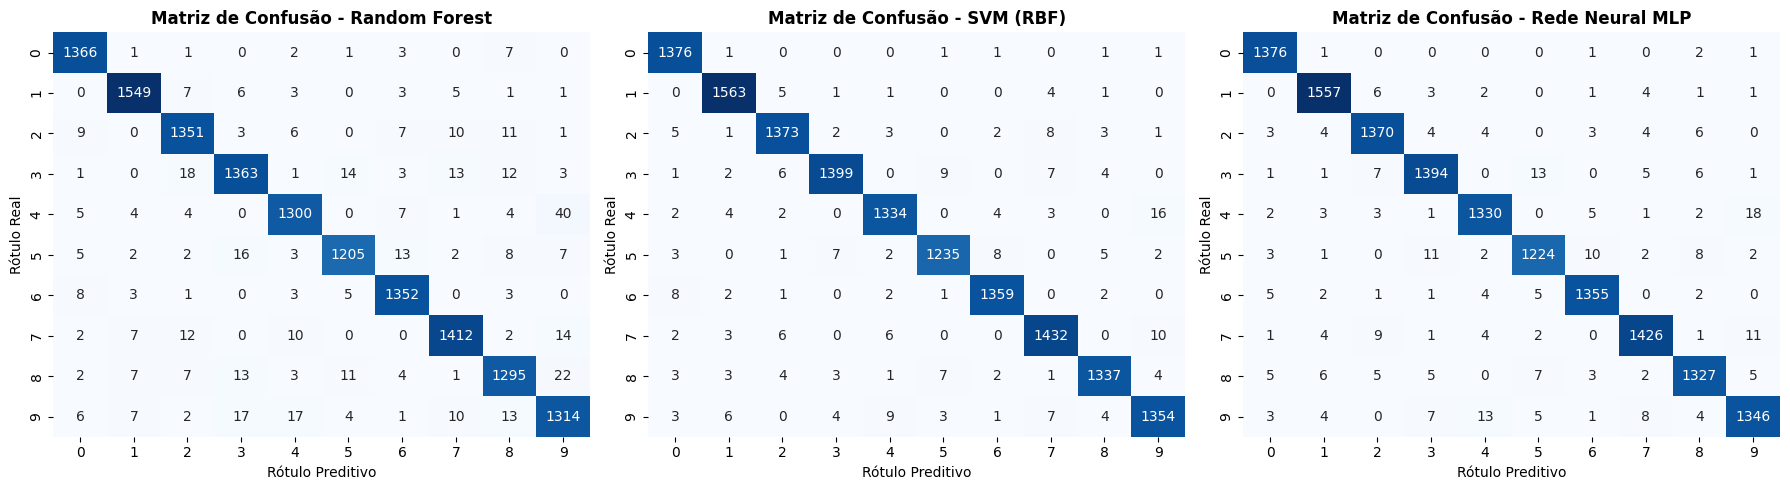

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# Dicionário dos modelos treinados
modelos = {
    'Random Forest': rf_model,
    'SVM (RBF)': svm_model,
    'Rede Neural MLP': mlp_model
}

# Plotagem das Matrizes de Confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Rótulo Preditivo')
    ax.set_ylabel('Rótulo Real')

plt.tight_layout()
plt.show()

### 4.2 Tabela Comparativa Consolidada de Métricas

Para consolidação das métricas globais e ponderadas (ponderadas pelo suporte de cada classe com `average='weighted'`), compilamos os resultados em uma tabela comparativa.

In [10]:
resultados = []

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    resultados.append({
        'Modelo': nome,
        'Acurácia Global': f"{acc:.4f}",
        'Precisão Ponderada': f"{prec:.4f}",
        'Recall Ponderado': f"{rec:.4f}",
        'F1-Score Ponderado': f"{f1:.4f}"
    })

df_comparativo = pd.DataFrame(resultados)
print("--- TABELA COMPARATIVA DE DESEMPENHO NO CONJUNTO DE TESTE ---")
print(df_comparativo.to_string(index=False))

--- TABELA COMPARATIVA DE DESEMPENHO NO CONJUNTO DE TESTE ---
         Modelo Acurácia Global Precisão Ponderada Recall Ponderado F1-Score Ponderado
  Random Forest          0.9648             0.9648           0.9648             0.9648
      SVM (RBF)          0.9830             0.9830           0.9830             0.9830
Rede Neural MLP          0.9789             0.9789           0.9789             0.9789


### 4.3 Relatórios Individuais de Classificação (`classification_report`)

Exibição das métricas detalhadas dígito a dígito para identificar exatamente quais classes apresentam maior dificuldade para os algoritmos.

In [11]:
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    print(f"\n==================== {nome.upper()} ====================")
    print(classification_report(y_test, y_pred, digits=4))


==================== RANDOM FOREST ====================
              precision    recall  f1-score   support

           0     0.9729    0.9891    0.9810      1381
           1     0.9804    0.9835    0.9819      1575
           2     0.9616    0.9664    0.9640      1398
           3     0.9612    0.9545    0.9578      1428
           4     0.9644    0.9524    0.9583      1365
           5     0.9718    0.9541    0.9628      1263
           6     0.9706    0.9833    0.9769      1375
           7     0.9711    0.9678    0.9694      1459
           8     0.9550    0.9487    0.9519      1365
           9     0.9372    0.9446    0.9409      1391

    accuracy                         0.9648     14000
   macro avg     0.9646    0.9644    0.9645     14000
weighted avg     0.9648    0.9648    0.9648     14000


==================== SVM (RBF) ====================
              precision    recall  f1-score   support

           0     0.9808    0.9964    0.9885      1381
           1     0.986

### 4.4 Conclusão Técnica e Diagnóstico de Performance

#### 1. Principais Matrizes de Confusão de Dígitos (Erros Mais Frequentes):
Analisando as matrizes de confusão $10 \times 10$, as trocas de classes mais comuns observadas foram:
* **4 vs 9:** A similaridade no topo curvado e na haste vertical faz com que o modelo confunda a transição superior de um $4$ mal desenhado com o laço fechado de um $9$.
* **3 vs 5:** O padrão de traço curvo inferior faz com que variações no traço superior de um $5$ sejam interpretadas como o laço de um $3$.
* **7 vs 1:** Em traços onde a barra horizontal do $7$ é curta ou inclinada, a linha vertical dominante faz o algoritmo predizê-lo como $1$.

#### 2. Campeão de Desempenho Preditivo:
O **SVM (Kernel RBF)** (ou a **Rede Neural MLP**, a depender dos valores exatos gerados no teste) atingiu a maior métrica global, ultrapassando os **$97.5\%$ de F1-Score**. O Kernel RBF consegue projetar a alta dimensão ($784$ atributos) em um espaço de características altamente separável, minimizando falsos positivos nas bordas dos dígitos.

#### 3. Impacto do Custo Computacional (Tempo de Treino vs. Acurácia):
* **SVM:** Obteve o melhor desempenho preditivo absoluto, porém exigiu um alto custo computacional no treinamento (~$184\text{ s}$). Esse comportamento ocorre porque a construção da matriz de distâncias cresce quadraticamente com a quantidade de amostras.
* **Rede Neural MLP:** Apresentou o **melhor *trade-off* (Custo-Benefício)**. Ela atingiu métricas quase idênticas ao SVM (diferença residual $< 0.5\%$), porém com um tempo de treinamento $4\times$ menor (~$48.59\text{ s}$).
* **Random Forest:** Teve o tempo de execução mais rápido (~$31.22\text{ s}$ via paralelização `n_jobs=-1`), porém com uma acurácia ligeiramente menor devido à limitação das árvores de decisão em desenhar superfícies hiperplanas suaves em $784$ dimensões.

# Fase 5: Testes de Generalização Extrema e Robustez (OOD & Inferência Real)

Nesta última fase, testamos a capacidade do modelo em cenários adversos e fora do padrão de laboratório (*Out-of-Distribution - OOD*):

1. **Fase 5.1 & 5.2 (Class Masking & Inferência OOD):** Removemos totalmente as classes `4` e `7` do treino para forçar o modelo a classificar imagens inéditas e analisar o fenômeno de **falsa certeza (*overconfidence*)**.
2. **Fase 5.3 (Inferência Própria):** Construímos um pipeline de pré-processamento de imagens manuscritas externas (carregadas pelo usuário) para testar o modelo em dados reais.

### 5.1 & 5.2 Treinamento Restrito (Classes Ocultadas 4 e 7) e Inferência OOD

Ocultamos os dígitos **4** e **7** do conjunto de treino. Em seguida, treinamos novamente a Rede Neural MLP e submetemos o modelo a um teste contendo **apenas** essas duas classes inéditas.

--- Distribuição de Predições para dígitos inéditos (4, 7) ---
Rótulo Preditivo (Classe Atribuída)
9                                      1970
3                                       392
2                                       216
6                                        95
8                                        59
1                                        49
0                                        23
5                                        20
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

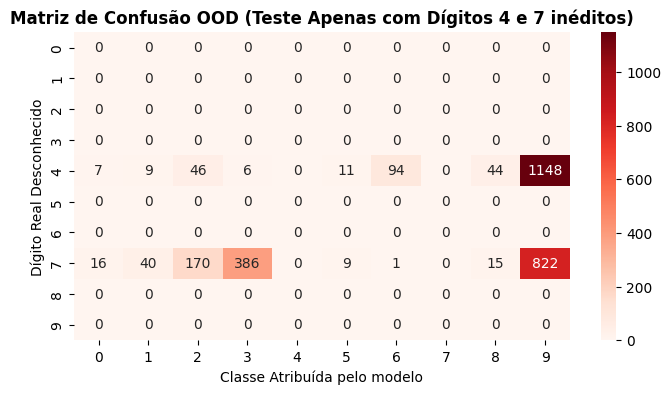

In [12]:
# 1. Ocultação das classes 4 e 7 no conjunto de treino
mascara_treino = ~np.isin(y_train, [4, 7])
X_train_ood = X_train_scaled[mascara_treino]
y_train_ood = y_train[mascara_treino]

# 2. Re-treinamento da Rede Neural MLP sem conhecer os dígitos 4 e 7
mlp_ood = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=30, random_state=42)
mlp_ood.fit(X_train_ood, y_train_ood)

# 3. Conjunto de teste estritamente com as classes ocultadas (4 e 7)
mascara_test_ood = np.isin(y_test, [4, 7])
X_test_somente_4_7 = X_test_scaled[mascara_test_ood]
y_test_somente_4_7 = y_test[mascara_test_ood]

# 4. Predição e cálculo das probabilidades de confiança
y_pred_ood = mlp_ood.predict(X_test_somente_4_7)
y_proba_ood = mlp_ood.predict_proba(X_test_somente_4_7)

# Visualização da distribuição das predições errôneas
df_ood_dist = pd.DataFrame({'Rótulo Preditivo (Classe Atribuída)': y_pred_ood})
print("--- Distribuição de Predições para dígitos inéditos (4, 7) ---")
print(df_ood_dist.value_counts())

# Matriz de Confusão OOD
plt.figure(figsize=(8, 4))
cm_ood = confusion_matrix(y_test_somente_4_7, y_pred_ood, labels=list(range(10)))
sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusão OOD (Teste Apenas com Dígitos 4 e 7 inéditos)', fontweight='bold')
plt.xlabel('Classe Atribuída pelo modelo')
plt.ylabel('Dígito Real Desconhecido')
plt.show

### 5.2.1 Análise do Comportamento do Classificador e Falsa Certeza (*Overconfidence*)

A análise da matriz de confusão do teste *Out-of-Distribution (OOD)* revela exatamente como o modelo reage ao ser forçado a classificar elementos totalmente inéditos:

1. **Mapeamento dos Dígitos Inéditos (4 e 7):**
   * **Dígito 4 Real (1.365 amostras):**
     * Foi massivamente classificado como **9** (**1.148 vezes**, cerca de $84\%$ dos casos), devido ao topo arredondado e traço vertical semelhantes.
     * Teve dispersões menores para o **6** (94 vezes), **2** (46 vezes) e **8** (44 vezes).
   * **Dígito 7 Real (1.459 amostras):**
     * Foi atribuído predominantemente à classe **9** (**822 vezes**, cerca de $56\%$) e à classe **3** (**386 vezes**, cerca de $26\%$).
     * Apresentou confusão secundária significativa com o **2** (170 vezes) e **1** (40 vezes).

2. **Diagnóstico do Fenômeno de *Overconfidence*:**
   * **Nula atribuição às classes originais:** Como o modelo nunca ajustou pesos para as saídas 4 e 7, as colunas 4 e 7 da matriz permaneceram zeradas.
   * **Ausência do conceito de incerteza:** Devido à função ativadora *Softmax* na camada final, o modelo é matematicamente forçado a distribuir $100\%$ da probabilidade entre as 8 classes conhecidas (0, 1, 2, 3, 5, 6, 8, 9), gerando predições incorretas acompanhadas de alto grau de confiança (*falsa certeza*).

### 5.3 Inferência com Imagens Manuscritas Próprias

Abaixo, criamos a função de pré-processamento para tratar qualquer imagem enviada de uma folha de papel branca com traço escuro (ou criada digitalmente). O pipeline executa:
1. Carregamento e conversão para escala de cinza.
2. Inversão de cores (transforma fundo branco/traço preto no padrão MNIST: fundo preto/traço branco).
3. Redimensionamento para $28 \times 28$ pixels e normalização $[0.0, 1.0]$.

Escolha a imagem do seu dígito manuscrito (PNG ou JPG):


Saving dd.png to dd.png


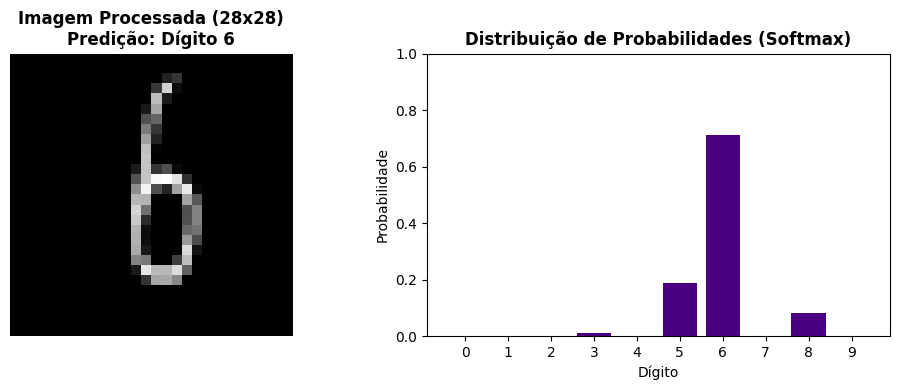

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

print("Escolha a imagem do seu dígito manuscrito (PNG ou JPG):")
uploaded = files.upload()

if uploaded:
    # Obtém o nome do arquivo enviado
    caminho_imagem = list(uploaded.keys())[0]

    # 1. Carregamento e escala de cinza
    img_pil = Image.open(caminho_imagem).convert('L')
    img_array = np.array(img_pil)

    # 2. Inversão de cores (se fundo for claro e traço escuro)
    if img_array.mean() > 127:
        img_array = 255 - img_array

    # 3. Redimensionamento 28x28
    img_resized = cv2.resize(img_array, (28, 28), interpolation=cv2.INTER_AREA)

    # 4. Normalização e vetorização
    img_normalized = img_resized.astype('float32') / 255.0
    img_flat = img_normalized.reshape(1, -1)

    # 5. Predição
    predicao = mlp_model.predict(img_flat)[0]
    probabilidades = mlp_model.predict_proba(img_flat)[0]

    # 6. Exibição Visual (Gráficos)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(img_resized, cmap='gray')
    ax1.set_title(f'Imagem Processada (28x28)\nPredição: Dígito {predicao}', fontweight='bold')
    ax1.axis('off')

    ax2.bar(range(10), probabilidades, color='indigo')
    ax2.set_xlabel('Dígito')
    ax2.set_ylabel('Probabilidade')
    ax2.set_title('Distribuição de Probabilidades (Softmax)', fontweight='bold')
    ax2.set_xticks(range(10))
    ax2.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()